In [2]:
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/data/cb/scratch/share/mihirb/")

In [1]:
import pandas as pd
df = pd.read_csv('/data/cb/scratch/share/mihirb/heme/hem_1_1k/results.csv')
df.mean(numeric_only=True)

plddt_0             0.565633
ptm_0               0.495475
plddt_1             0.566220
ptm_1               0.535016
cross_rmsd_mean     6.096893
cross_rmsd_std      2.169935
intra_rmsd0_mean    5.877107
intra_rmsd0_std     2.112882
intra_rmsd1_mean    5.292274
intra_rmsd1_std     1.659841
dtype: float64

In [76]:
df[(df.cross_rmsd_mean > 2) & (df.intra_rmsd0_mean < 1) & (df.intra_rmsd1_mean < 1)]

,sample,plddt_0,ptm_0,plddt_1,ptm_1,cross_rmsd_mean,cross_rmsd_std,intra_rmsd0_mean,intra_rmsd0_std,intra_rmsd1_mean,intra_rmsd1_std
87,design206,0.742863,0.682268,0.772303,0.817953,9.630365,0.178731,0.846571,0.147036,0.834351,0.309587
95,design225,0.690789,0.728178,0.724720,0.752196,2.757778,0.168815,0.610825,0.138142,0.568225,0.117012
165,design326,0.894044,0.935481,0.908250,0.944766,2.282209,0.071020,0.325879,0.061719,0.325549,0.069303
266,design457,0.611791,0.557611,0.859934,0.923103,2.700668,0.146394,0.983659,0.172897,0.373595,0.090214
296,design494,0.592824,0.635964,0.648358,0.707616,3.282579,0.271735,0.593319,0.077841,0.577473,0.105774
301,design499,0.684289,0.638977,0.810136,0.821322,6.978830,0.182525,0.878218,0.337060,0.532132,0.161248
370,design6,0.683604,0.688328,0.823356,0.870561,3.738751,0.298553,0.526513,0.100621,0.958398,0.249630
379,design616,0.621872,0.586846,0.656136,0.625622,6.148844,0.187126,0.802051,0.088253,0.889201,0.316853
383,design620,0.812005,0.804804,0.907544,0.942391,3.755672,0.084049,0.828070,0.391875,0.260805,0.046720
557,design999,0.668677,0.590943,0.708585,0.702140,4.074073,0.197403,0.864113,0.190286,0.834276,0.245895


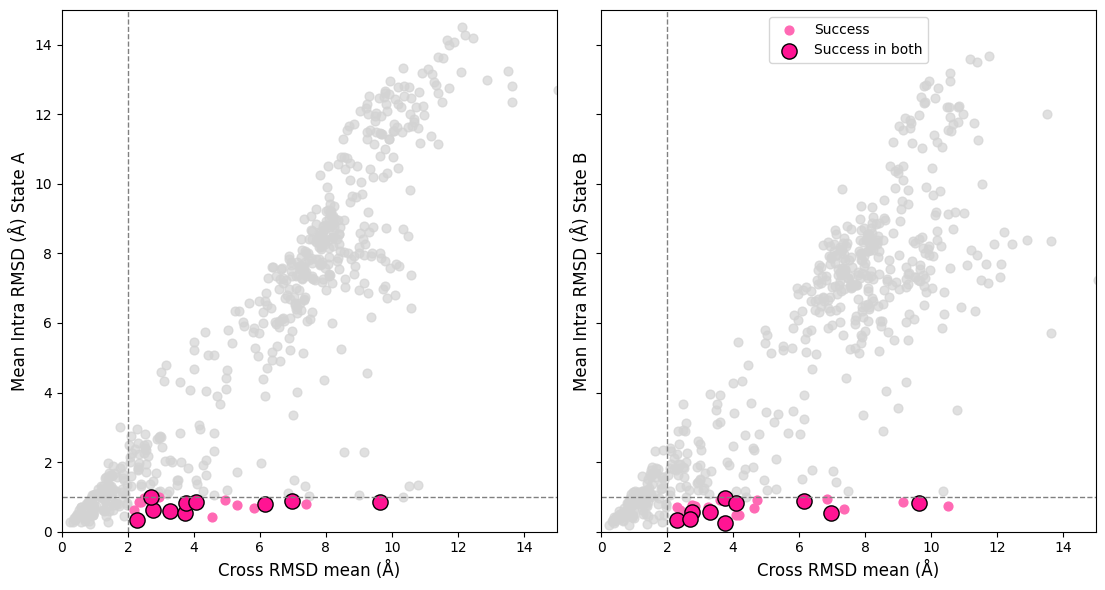

In [77]:
import matplotlib.pyplot as plt

df = df.copy()

# success in intra0 vs cross
success0 = (df["cross_rmsd_mean"] > 2) & (df["intra_rmsd0_mean"] < 1)

# success in intra1 vs cross
success1 = (df["cross_rmsd_mean"] > 2) & (df["intra_rmsd1_mean"] < 1)

# intersection
intersection = success0 & success1

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

def plot_one(ax, x, y, ylabel, title, success_mask):
    # others
    ax.scatter(
        df.loc[~success_mask, x],
        df.loc[~success_mask, y],
        c="lightgray",
        alpha=0.7, s=40
    )

    # successes (excluding intersection)
    ax.scatter(
        df.loc[success_mask & ~intersection, x],
        df.loc[success_mask & ~intersection, y],
        c="hotpink", s=40, label="Success"
    )

    # intersection = bigger deep pink
    ax.scatter(
        df.loc[intersection, x],
        df.loc[intersection, y],
        c="deeppink", s=120, edgecolors="black", linewidth=1.0, label="Success in both"
    )

    # axes limits
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 15)

    # labels
    ax.set_xlabel("Cross RMSD mean (Å)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)

    # thresholds
    ax.axvline(2, color="gray", ls="--", lw=1)
    ax.axhline(1, color="gray", ls="--", lw=1)
    ax.set_rasterized(True)

# left subplot (intra0)
plot_one(axes[0], "cross_rmsd_mean", "intra_rmsd0_mean",
         "Mean Intra RMSD (Å) State A", "", success0)

# right subplot (intra1)
plot_one(axes[1], "cross_rmsd_mean", "intra_rmsd1_mean",
         "Mean Intra RMSD (Å) State B", "", success1)
axes[1].legend()
# shared legend
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="center right", frameon=True)

plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("./plots/scatter_liganddiscrimination.pdf", bbox_inches="tight", dpi=200)
plt.show()


In [3]:
import pandas as pd
df = pd.read_csv('/data/cb/scratch/share/mihirb/top7/results.csv')
df.mean(numeric_only=True)

plddt_0                      0.651261
ptm_0                        0.587050
plddt_1                      0.698034
ptm_1                        0.643901
state0_target_iptm_mean      0.386855
state1_target_iptm_mean      0.467205
state1_effector_iptm_mean    0.344210
state0_target_iptm_std       0.072493
state1_target_iptm_std       0.082786
state1_effector_iptm_std     0.092698
cross_rmsd_mean              3.257954
cross_rmsd_std               1.006462
intra_rmsd0_mean             2.467427
intra_rmsd0_std              0.927688
intra_rmsd1_mean             2.084546
intra_rmsd1_std              0.820950
dtype: float64

In [4]:
df[(df.state1_target_iptm_mean > 0.6) & (df.state0_target_iptm_mean < 0.6) & (df.cross_rmsd_mean > 3) & (df.intra_rmsd0_mean < 2) & (df.intra_rmsd1_mean < 2)]

,sample,plddt_0,ptm_0,plddt_1,ptm_1,state0_target_iptm_mean,state1_target_iptm_mean,state1_effector_iptm_mean,state0_target_iptm_std,state1_target_iptm_std,state1_effector_iptm_std,cross_rmsd_mean,cross_rmsd_std,intra_rmsd0_mean,intra_rmsd0_std,intra_rmsd1_mean,intra_rmsd1_std
105,design193,0.714142,0.659509,0.759603,0.705449,0.559885,0.659506,0.161994,0.019266,0.015048,0.022452,3.598846,0.221894,0.712794,0.162056,1.287961,0.850282
732,design758,0.676489,0.633980,0.745650,0.749540,0.390166,0.637528,0.424778,0.053974,0.107378,0.185674,4.503378,0.420396,1.078131,0.285020,1.365877,0.354588
796,design815,0.673664,0.568996,0.882165,0.867831,0.165659,0.891161,0.657088,0.062830,0.006692,0.154400,3.012727,0.263643,1.758516,0.865017,0.736395,0.246537
811,design829,0.745501,0.567700,0.851553,0.766014,0.538323,0.786387,0.511612,0.105801,0.046543,0.109713,3.599560,0.561568,1.685169,0.563019,1.059395,0.244656
864,design877,0.578322,0.483027,0.649242,0.551052,0.082156,0.681531,0.493106,0.032168,0.051372,0.083978,4.521893,0.383520,1.350601,0.459604,1.908240,0.741171
869,design881,0.572935,0.485465,0.858417,0.798954,0.118510,0.878231,0.621545,0.036589,0.009695,0.043547,12.495152,0.173853,1.079434,0.221445,0.785701,0.139376
881,design892,0.688263,0.704243,0.830255,0.829097,0.240438,0.740319,0.439580,0.054244,0.027423,0.041761,4.485422,0.096502,0.544846,0.101913,0.389375,0.098940
926,design94,0.705777,0.572336,0.824519,0.806770,0.337057,0.648536,0.926063,0.026644,0.078850,0.002815,7.365346,0.244366,0.877596,0.296191,0.567780,0.135332


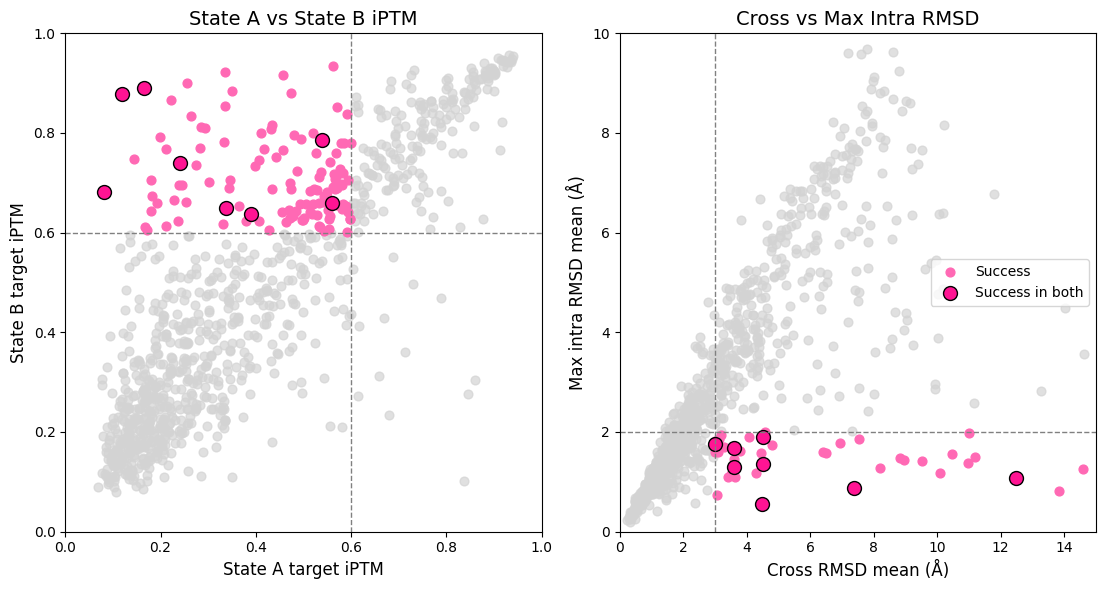

In [5]:
import matplotlib.pyplot as plt

df = df.copy()

# split success conditions
iptm_success = (
    (df["state1_target_iptm_mean"] > 0.6) &
    (df["state0_target_iptm_mean"] < 0.6)
)

rmsd_success = (
    (df["cross_rmsd_mean"] > 3) &
    (df["intra_rmsd0_mean"] < 2) &
    (df["intra_rmsd1_mean"] < 2)
)

# intersection
intersection = iptm_success & rmsd_success

# for second plot, y = max intra RMSD
df["intra_rmsd_max"] = df[["intra_rmsd0_mean", "intra_rmsd1_mean"]].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

def plot_one(ax, x, y, xlabel, ylabel, title, mask, xline=None, yline=None):
    # others
    ax.scatter(
        df.loc[~mask, x],
        df.loc[~mask, y],
        c="lightgray",
        alpha=0.7, s=40
    )

    # successes (excluding intersection)
    ax.scatter(
        df.loc[mask & ~intersection, x],
        df.loc[mask & ~intersection, y],
        c="hotpink", s=40, label="Success"
    )

    # intersection = bigger deep pink
    ax.scatter(
        df.loc[intersection, x],
        df.loc[intersection, y],
        c="deeppink", s=100, edgecolors="black", linewidth=1.0,
        label="Success in both"
    )

    # boundaries
    if xline is not None:
        ax.axvline(xline, color="gray", ls="--", lw=1)
    if yline is not None:
        ax.axhline(yline, color="gray", ls="--", lw=1)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_rasterized(True)


# Plot 1: state0 vs state1 iPTM
plot_one(
    axes[0],
    "state0_target_iptm_mean",
    "state1_target_iptm_mean",
    "State A target iPTM",
    "State B target iPTM",
    "State A vs State B iPTM",
    iptm_success,
    xline=0.6, yline=0.6
)

# Plot 2: cross vs max intra RMSD
plot_one(
    axes[1],
    "cross_rmsd_mean",
    "intra_rmsd_max",
    "Cross RMSD mean (Å)",
    "Max intra RMSD mean (Å)",
    "Cross vs Max Intra RMSD",
    rmsd_success,
    xline=3, yline=2
)
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)
axes[1].set_xlim(0,15)
axes[1].set_ylim(0,10)
# shared legend
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(loc="center right", frameon=True)

plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("./plots/scatter_inducedbinding.pdf",dpi=200,bbox_inches="tight")
plt.show()


In [6]:
import pandas as pd
df = pd.read_csv('/data/cb/scratch/share/mihirb/oqo_ca/results.csv')
df.mean(numeric_only=True)

plddt_0               0.686698
ptm_0                 0.173746
plddt_1               0.562364
ptm_1                 0.416516
plddt_2               0.602501
ptm_2                 0.248318
cross_rmsd01_mean    11.226299
cross_rmsd01_std      4.581000
cross_rmsd02_mean     5.777081
cross_rmsd02_std      4.242920
cross_rmsd12_mean    13.785048
cross_rmsd12_std      2.142022
intra_rmsd0_mean      6.528994
intra_rmsd0_std       4.617717
intra_rmsd1_mean      4.157187
intra_rmsd1_std       2.636499
intra_rmsd2_mean      2.916880
intra_rmsd2_std       1.258379
dtype: float64

In [7]:
a = 1
b = 1
df[
    (df.intra_rmsd0_mean < a) & \
    (df.intra_rmsd1_mean < a) & \
    (df.intra_rmsd2_mean < a) & \
    (df.cross_rmsd01_mean > b) & \
    (df.cross_rmsd12_mean > b) & \
    (df.cross_rmsd02_mean > b)
]

,sample,plddt_0,ptm_0,plddt_1,ptm_1,plddt_2,ptm_2,cross_rmsd01_mean,cross_rmsd01_std,cross_rmsd02_mean,cross_rmsd02_std,cross_rmsd12_mean,cross_rmsd12_std,intra_rmsd0_mean,intra_rmsd0_std,intra_rmsd1_mean,intra_rmsd1_std,intra_rmsd2_mean,intra_rmsd2_std
35,design13,0.822130,0.736021,0.775238,0.781946,0.840276,0.830588,2.622879,0.128039,1.392220,0.187376,2.227972,0.150769,0.647828,0.121563,0.545830,0.108288,0.760151,0.187579
122,design208,0.725432,0.528404,0.667793,0.632054,0.813850,0.728320,2.463100,0.157426,1.015938,0.226111,2.116397,0.154627,0.893226,0.220766,0.676162,0.155606,0.749821,0.118041
145,design229,0.734415,0.505788,0.715257,0.674033,0.868649,0.791579,1.806914,0.219778,2.896498,0.211865,1.933316,0.176797,0.924255,0.195055,0.881614,0.142680,0.620196,0.140430
170,design251,0.751861,0.578059,0.848641,0.904488,0.864272,0.889864,1.479989,0.138360,2.899621,0.093755,2.427514,0.087525,0.531523,0.126357,0.313978,0.041861,0.206948,0.030538
215,design292,0.827815,0.598281,0.728717,0.733707,0.878165,0.816023,1.512639,0.153827,1.386852,0.107941,2.087698,0.113515,0.378436,0.085687,0.696791,0.204948,0.453449,0.159561
253,design326,0.784947,0.551015,0.659021,0.635825,0.907244,0.868120,1.342457,0.153081,1.729916,0.156902,2.055056,0.112924,0.788750,0.219958,0.760290,0.214616,0.497760,0.131748
313,design380,0.678436,0.441543,0.811393,0.856915,0.920669,0.907432,1.126617,0.224952,1.044281,0.273050,1.498847,0.237636,0.854795,0.136415,0.771764,0.422671,0.199807,0.028194
329,design395,0.733185,0.564603,0.681286,0.708336,0.789360,0.761092,1.462450,0.157749,1.675364,0.144502,1.898578,0.210705,0.570911,0.087746,0.543794,0.074631,0.826216,0.137346
347,design410,0.765694,0.531989,0.746449,0.699447,0.811598,0.724729,2.710764,0.132004,1.469099,0.349016,3.256258,0.160821,0.973770,0.342700,0.552953,0.095769,0.729846,0.166742
374,design435,0.725987,0.589595,0.655841,0.611412,0.854011,0.841061,2.260888,0.127036,1.105389,0.247098,2.204570,0.087065,0.964415,0.369859,0.529784,0.095563,0.604648,0.088714


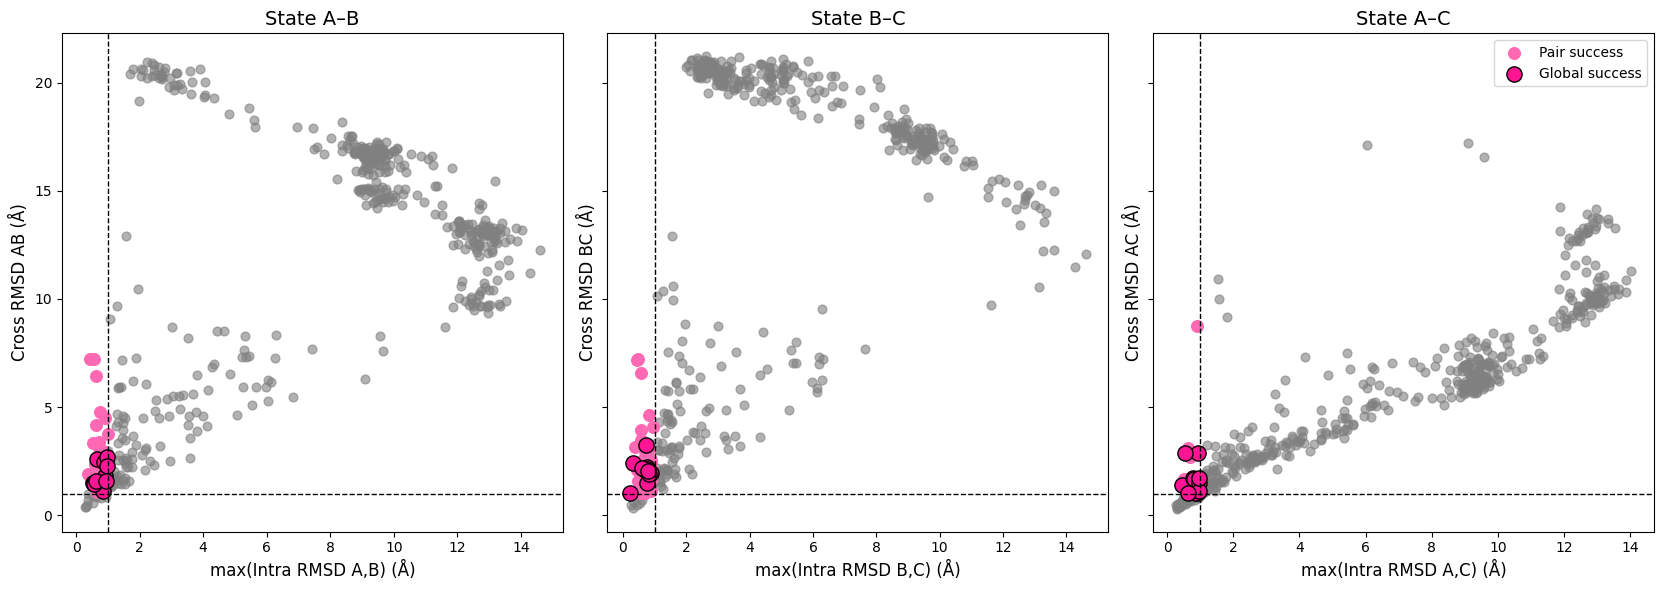

In [8]:
import matplotlib.pyplot as plt

a = 1
b = 1

df = df.copy()

# global success mask (intersection across all conditions)
global_success = (
    (df["intra_rmsd0_mean"] < a) &
    (df["intra_rmsd1_mean"] < a) &
    (df["intra_rmsd2_mean"] < a) &
    (df["cross_rmsd01_mean"] > b) &
    (df["cross_rmsd12_mean"] > b) &
    (df["cross_rmsd02_mean"] > b)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

pairs = [
    ("0", "1", "cross_rmsd01_mean"),
    ("1", "2", "cross_rmsd12_mean"),
    ("0", "2", "cross_rmsd02_mean")
]

for ax, (s1, s2, cross_col) in zip(axes, pairs):
    # per-pair success condition
    pair_success = (
        (df[f"intra_rmsd{s1}_mean"] < a) &
        (df[f"intra_rmsd{s2}_mean"] < a) &
        (df[cross_col] > b)
    )
    intra_max = df[[f"intra_rmsd{s1}_mean", f"intra_rmsd{s2}_mean"]].max(axis=1)
    cross_val = df[cross_col]

    # non-successes
    ax.scatter(
        intra_max[~pair_success],
        cross_val[~pair_success],
        c="gray", s=40, alpha=0.6
    )

    # pair-only successes
    ax.scatter(
        intra_max[pair_success & ~global_success],
        cross_val[pair_success & ~global_success],
        c="hotpink", s=70, label="Pair success"
    )

    # global successes (intersection across all pairs)
    ax.scatter(
        intra_max[global_success],
        cross_val[global_success],
        c="deeppink", s=120, edgecolors="black", linewidth=1.0,
        label="Global success"
    )

    # thresholds
    ax.axvline(a, color="black", ls="--", lw=1)
    ax.axhline(b, color="black", ls="--", lw=1)

    if s1 == "0":
        s1 = "A"
    elif s1 == "1":
        s1 = "B"
    elif s1 == "2":
        s1 = "C"
        
        
    if s2 == "0":
        s2 = "A"
    elif s2 == "1":
        s2 = "B"
    elif s2 == "2":
        s2 = "C"
    # labels
    ax.set_xlabel(f"max(Intra RMSD {s1},{s2}) (Å)", fontsize=12)
    ax.set_ylabel(f"Cross RMSD {s1}{s2} (Å)", fontsize=12)
    ax.set_title(f"State {s1}–{s2}", fontsize=14)
    ax.set_rasterized(True)
# shared legend
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="center right", frameon=True)
axes[2].legend()
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("./plots/scatter_liganddiscrimination.pdf", dpi=200,bbox_inches="tight")
plt.show()


In [9]:
from utils.motif_utils import get_motif_scaffold_templates

get_motif_scaffold_templates(["./motifs/3ixt.pdb","./motifs/1ycr.pdb"])
    

[{'full_motif_mask': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False]),
  'motif_mask